<a href="https://colab.research.google.com/github/TH-Koo/2026-1_CV/blob/main/2023078074_HW3_CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW#MLP 신경망 성능에 영향을 주는 요소별 실험 및 분석

 **실험 A → 실험 B → 실험 C** 순서로 진행

- **실험 A**: 손실 함수 비교  
  - CrossEntropyLoss vs MSELoss with Softmax
- **실험 B**: 활성화 함수 비교  
  - ReLU vs LeakyReLU vs Sigmoid
- **실험 C**: 최적화 알고리즘 비교  
  - SGD vs SGD+Momentum vs Adam

결과:

- Loss / Accuracy 그래프
- Gradient Flow 그래프
- Activation 분포 히스토그램
- Dead ReLU 비율 히트맵
- Optimizer 비교표
- 전체 결과 CSV 파일

> 실행 환경: Google Colab (T4 GPU)

## 0. 라이브러리 import 및 공통 환경 설정

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 장치:", DEVICE)

RESULT_DIR = "results"
os.makedirs(RESULT_DIR, exist_ok=True)

summary_rows = []


사용 장치: cuda


## 1. 공통 함수 정의

실험 A, B, C에서 공통으로 사용할 데이터 로딩 함수, 모델 클래스, 학습 함수, 평가 함수, 시각화 함수 정의

In [2]:
#실험 A, C에서 사용할 Digits Dataset
def get_digits_loaders(batch_size=64):
    digits = load_digits()
    X = digits.data.astype(np.float32)
    y = digits.target.astype(np.int64)
    scaler = StandardScaler()
    X = scaler.fit_transform(X).astype(np.float32)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=SEED,
        stratify=y
    )

    train_dataset = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long)
    )
    test_dataset = TensorDataset(
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.long)
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader, 64, 10

#실험 B에서 사용할 make_moons Dataset
def get_moons_loaders(batch_size=64, n_samples=1500, noise=0.25):
    X, y = make_moons(n_samples=n_samples, noise=noise, random_state=SEED)
    X = X.astype(np.float32)
    y = y.astype(np.int64)
    scaler = StandardScaler()
    X = scaler.fit_transform(X).astype(np.float32)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=SEED,
        stratify=y
    )

    train_dataset = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long)
    )
    test_dataset = TensorDataset(
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test, dtype=torch.long)
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader, X_train, X_test, y_train, y_test, 2, 2

#Digits Dataset MLP 모델
class MLP(nn.Module):
    def __init__(self, input_size, num_classes, activation_name="relu", small_init=False):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 256)
        self.act1 = self._get_activation(activation_name)

        self.fc2 = nn.Linear(256, 128)
        self.act2 = self._get_activation(activation_name)

        self.fc3 = nn.Linear(128, num_classes)

        self.activations = {}

        if small_init:
            self.apply(self._small_weight_init)
  #활성함수 선택
    def _get_activation(self, activation_name):
        if activation_name == "relu":
            return nn.ReLU()
        elif activation_name == "leaky_relu":
            return nn.LeakyReLU(negative_slope=0.01)
        elif activation_name == "sigmoid":
            return nn.Sigmoid()
        else:
            raise ValueError("지원하지 않는 activation: " + activation_name)

    def _small_weight_init(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.01)
            nn.init.constant_(module.bias, 0.0)

    def forward(self, x):
        z1 = self.fc1(x)
        a1 = self.act1(z1)
        self.activations["layer1"] = a1.detach()

        z2 = self.fc2(a1)
        a2 = self.act2(z2)
        self.activations["layer2"] = a2.detach()

        logits = self.fc3(a2)
        return logits

#make_moons MLP 모델
class SmallMLP(nn.Module):
    def __init__(self, activation_name="relu", small_init=True):
        super().__init__()

        self.fc1 = nn.Linear(2, 64)
        self.act1 = self._get_activation(activation_name)
        self.fc2 = nn.Linear(64, 64)
        self.act2 = self._get_activation(activation_name)
        self.fc3 = nn.Linear(64, 2)

        self.activations = {}

        if small_init:
            self.apply(self._small_weight_init)

    def _get_activation(self, activation_name):
        if activation_name == "relu":
            return nn.ReLU()
        elif activation_name == "leaky_relu":
            return nn.LeakyReLU(negative_slope=0.01)
        elif activation_name == "sigmoid":
            return nn.Sigmoid()
        else:
            raise ValueError("지원하지 않는 activation입니다: " + activation_name)

    def _small_weight_init(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.01)
            nn.init.constant_(module.bias, 0.0)

    def forward(self, x):
        z1 = self.fc1(x)
        a1 = self.act1(z1)
        self.activations["layer1"] = a1.detach()

        z2 = self.fc2(a1)
        a2 = self.act2(z2)
        self.activations["layer2"] = a2.detach()

        logits = self.fc3(a2)
        return logits

# average loss, accuracy 계산
def evaluate_model(model, data_loader, loss_mode="ce", loss_fn=None, num_classes=None):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(DEVICE)
            targets = targets.to(DEVICE)

            logits = model(inputs)

            if loss_mode == "ce":
                loss = loss_fn(logits, targets)
                preds = torch.argmax(logits, dim=1)
            elif loss_mode == "mse":
                probs = torch.softmax(logits, dim=1)
                targets_onehot = torch.nn.functional.one_hot(targets, num_classes=num_classes).float()
                loss = loss_fn(probs, targets_onehot)
                preds = torch.argmax(probs, dim=1)
            else:
                raise ValueError("지원하지 않는 loss_mode")

            total_loss += loss.item() * inputs.size(0)
            total_correct += (preds == targets).sum().item()
            total_count += inputs.size(0)

    return total_loss / total_count, total_correct / total_count


def compute_gradient_norms(model):
    grad_norms = {}
    for name, param in model.named_parameters():
        if param.grad is not None and "weight" in name:
            grad_norms[name] = param.grad.detach().norm().item()
    return grad_norms

#학습, 평가, gradient 기록 함수
def train_model(model, train_loader, test_loader, optimizer, loss_fn,
                epochs=50, loss_mode="ce", num_classes=None, scheduler=None):
    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
        "grad_norms": []
    }

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_count = 0
        epoch_grad_norms = []

        for inputs, targets in train_loader:
            inputs = inputs.to(DEVICE)
            targets = targets.to(DEVICE)

            optimizer.zero_grad()

            logits = model(inputs)

            if loss_mode == "ce":
                loss = loss_fn(logits, targets)
                preds = torch.argmax(logits, dim=1)
            elif loss_mode == "mse":
                probs = torch.softmax(logits, dim=1)
                targets_onehot = torch.nn.functional.one_hot(targets, num_classes=num_classes).float()
                loss = loss_fn(probs, targets_onehot)
                preds = torch.argmax(probs, dim=1)
            else:
                raise ValueError("지원하지 않는 loss_mode입니다.")

            loss.backward()

            epoch_grad_norms.append(compute_gradient_norms(model))

            optimizer.step()

            total_loss += loss.item() * inputs.size(0)
            total_correct += (preds == targets).sum().item()
            total_count += inputs.size(0)

        if scheduler is not None:
            scheduler.step()

        train_loss = total_loss / total_count
        train_acc = total_correct / total_count

        test_loss, test_acc = evaluate_model(
            model, test_loader, loss_mode=loss_mode, loss_fn=loss_fn, num_classes=num_classes
        )

        avg_grad_norms = {}
        if len(epoch_grad_norms) > 0:
            keys = epoch_grad_norms[0].keys()
            for key in keys:
                avg_grad_norms[key] = np.mean([g[key] for g in epoch_grad_norms if key in g])

        #결과 저장
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["grad_norms"].append(avg_grad_norms)

        # 진행 상황 출력, 10 epoch
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(
                f"Epoch [{epoch+1:03d}/{epochs}] "
                f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
                f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}"
            )

    return history


def get_convergence_epoch(acc_list, threshold=0.90):
    """정확도가 기준값 이상에 처음 도달한 epoch를 찾는 함수"""
    for i, acc in enumerate(acc_list):
        if acc >= threshold:
            return i + 1
    return None


def plot_loss_accuracy(histories, title, save_path):
    """여러 조건의 test loss와 test accuracy를 한 그림에 비교"""
    plt.figure(figsize=(12, 5))

    # 그래프1: test loss 변화
    plt.subplot(1, 2, 1)
    for label, history in histories.items():
        plt.plot(history["test_loss"], label=label)
    plt.title(title + " - Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # 그래프2: test accuracy 변화
    plt.subplot(1, 2, 2)
    for label, history in histories.items():
        plt.plot(history["test_acc"], label=label)
    plt.title(title + " - Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()


def plot_gradient_flow(histories, title, save_path):
    """조건별 첫 번째 layer의 gradient norm 변화"""
    plt.figure(figsize=(12, 6))

    for label, history in histories.items():
        fc1_grad = [grad_dict.get("fc1.weight", np.nan) for grad_dict in history["grad_norms"]]
        plt.plot(fc1_grad, label=f"{label} - fc1.weight")

    plt.title(title + " - Gradient Flow")
    plt.xlabel("Epoch")
    plt.ylabel("Gradient Norm")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()


def plot_activation_distribution(model, data_loader, title, save_path):
    """학습된 모델의 layer별 activation 값 분포 히스토그램"""
    model.eval()
    all_activations = {"layer1": [], "layer2": []}

    with torch.no_grad():
        for inputs, _ in data_loader:
            inputs = inputs.to(DEVICE)
            _ = model(inputs)

            for layer_name in all_activations.keys():
                all_activations[layer_name].append(model.activations[layer_name].cpu().numpy().ravel())

    layer1_vals = np.concatenate(all_activations["layer1"])
    layer2_vals = np.concatenate(all_activations["layer2"])

    plt.figure(figsize=(12, 5))

    # layer1 activation 분포
    plt.subplot(1, 2, 1)
    plt.hist(layer1_vals, bins=50)
    plt.title(title + " - Layer 1 Activation")
    plt.xlabel("Activation Value")
    plt.ylabel("Frequency")
    plt.grid(True)

    # layer2 activation 분포
    plt.subplot(1, 2, 2)
    plt.hist(layer2_vals, bins=50)
    plt.title(title + " - Layer 2 Activation")
    plt.xlabel("Activation Value")
    plt.ylabel("Frequency")
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()


def calculate_dead_ratio(model, data_loader, activation_name):
    """activation 값이 0에 가까운 비율을 계산하여 Dead ReLU 정도 측정"""
    model.eval()
    dead_ratios = {"layer1": [], "layer2": []}

    with torch.no_grad():
        for inputs, _ in data_loader:
            inputs = inputs.to(DEVICE)
            _ = model(inputs)

            for layer_name in dead_ratios.keys():
                acts = model.activations[layer_name]

                if activation_name == "relu":
                    dead_ratio = (acts == 0).float().mean().item()
                else:
                    dead_ratio = (torch.abs(acts) < 1e-6).float().mean().item()

                dead_ratios[layer_name].append(dead_ratio)

    return {
        "layer1": np.mean(dead_ratios["layer1"]),
        "layer2": np.mean(dead_ratios["layer2"])
    }


def plot_dead_relu_heatmap(dead_ratio_table, save_path):
    """활성화 함수별 layer1/layer2 Dead 비율을 heatmap 시각화"""
    labels = list(dead_ratio_table.keys())
    data = np.array([
        [dead_ratio_table[label]["layer1"], dead_ratio_table[label]["layer2"]]
        for label in labels
    ])

    plt.figure(figsize=(7, 4))
    plt.imshow(data, aspect="auto")
    plt.colorbar(label="Dead Ratio")
    plt.xticks([0, 1], ["Layer 1", "Layer 2"])
    plt.yticks(range(len(labels)), labels)
    plt.title("Dead ReLU Ratio Heatmap")

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            plt.text(j, i, f"{data[i, j] * 100:.2f}%", ha="center", va="center")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()


def plot_decision_boundary(model, X, y, title, save_path):
    """2차원 입력 공간에서 모델의 분류 경계를 시각화"""
    model.eval()

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    grid_tensor = torch.tensor(grid, dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        logits = model(grid_tensor)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

    Z = preds.reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", s=20)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()


# 실험 A. 손실 함수 비교

## A-0. 실험 조건

- 데이터셋: Digits Dataset
- 모델 구조: 64 → 256 → 128 → 10
- 활성화 함수: ReLU
- Optimizer: Adam
- Learning Rate: 0.001
- Epoch: 50
- 비교 대상: CrossEntropyLoss, MSELoss with Softmax

In [3]:
print("실험 A: 손실 함수 비교")

# Digits Dataset 로딩
train_loader_digits_A, test_loader_digits_A, input_size_digits_A, num_classes_digits_A = get_digits_loaders(batch_size=64)

# CrossEntropy와 MSE의 학습 기록 저장
expA_histories = {}


실험 A: 손실 함수 비교


## A-1. CrossEntropyLoss 실험

CrossEntropyLoss는 내부적으로 softmax와 log 연산을 포함하므로 모델 출력 logits를 그대로 사용

In [4]:
# 같은 초기 weight에서 실험을 시작하기 위해 seed 고정
torch.manual_seed(SEED)

# CrossEntropyLoss 실험용 MLP 모델을 생성
model_ce = MLP(
    input_size=input_size_digits_A,
    num_classes=num_classes_digits_A,
    activation_name="relu"
).to(DEVICE)

# CrossEntropyLoss 손실 함수
loss_fn_ce = nn.CrossEntropyLoss()

# Adam optimizer, parameter별 적응형 learning rate
optimizer_ce = optim.Adam(model_ce.parameters(), lr=0.001)

# CrossEntropyLoss는 logits와 정수 label을 그대로 사용하므로 loss_mode를 "ce"로 지정
history_ce = train_model(
    model=model_ce,
    train_loader=train_loader_digits_A,
    test_loader=test_loader_digits_A,
    optimizer=optimizer_ce,
    loss_fn=loss_fn_ce,
    epochs=50,
    loss_mode="ce",
    num_classes=num_classes_digits_A
)

# 학습 결과 저장
expA_histories["CrossEntropy"] = history_ce


Epoch [001/50] Train Loss: 1.7479, Train Acc: 0.6500, Test Loss: 1.0614, Test Acc: 0.8000
Epoch [010/50] Train Loss: 0.0171, Train Acc: 0.9986, Test Loss: 0.1016, Test Acc: 0.9694
Epoch [020/50] Train Loss: 0.0032, Train Acc: 1.0000, Test Loss: 0.0979, Test Acc: 0.9722
Epoch [030/50] Train Loss: 0.0013, Train Acc: 1.0000, Test Loss: 0.0998, Test Acc: 0.9750
Epoch [040/50] Train Loss: 0.0007, Train Acc: 1.0000, Test Loss: 0.1018, Test Acc: 0.9722
Epoch [050/50] Train Loss: 0.0004, Train Acc: 1.0000, Test Loss: 0.1043, Test Acc: 0.9750


## A-2. MSELoss with Softmax 실험

MSELoss는 확률값과 one-hot label 사이의 차이를 계산하므로 softmax와 one-hot 변환을 명시적으로 적용

In [5]:
# 동일한 초기 조건 위해 seed 고정
torch.manual_seed(SEED)

# MSELoss 실험용 MLP 모델을 생성
model_mse = MLP(
    input_size=input_size_digits_A,
    num_classes=num_classes_digits_A,
    activation_name="relu"
).to(DEVICE)

# MSELoss, 예측값과 target 값 사이의 평균제곱오차를 계산
loss_fn_mse = nn.MSELoss()

# optimizer와 learning rate는 CrossEntropy 실험과 동일
optimizer_mse = optim.Adam(model_mse.parameters(), lr=0.001)

# MSELoss 실험에서는 내부적으로 softmax와 one-hot 변환이 수행되도록 loss_mode를 "mse"로 지정
history_mse = train_model(
    model=model_mse,
    train_loader=train_loader_digits_A,
    test_loader=test_loader_digits_A,
    optimizer=optimizer_mse,
    loss_fn=loss_fn_mse,
    epochs=50,
    loss_mode="mse",
    num_classes=num_classes_digits_A
)

# 학습 결과 저장
expA_histories["MSE with Softmax"] = history_mse


Epoch [001/50] Train Loss: 0.0721, Train Acc: 0.6054, Test Loss: 0.0447, Test Acc: 0.7389
Epoch [010/50] Train Loss: 0.0006, Train Acc: 0.9979, Test Loss: 0.0038, Test Acc: 0.9750
Epoch [020/50] Train Loss: 0.0001, Train Acc: 1.0000, Test Loss: 0.0038, Test Acc: 0.9750
Epoch [030/50] Train Loss: 0.0000, Train Acc: 1.0000, Test Loss: 0.0037, Test Acc: 0.9750
Epoch [040/50] Train Loss: 0.0000, Train Acc: 1.0000, Test Loss: 0.0037, Test Acc: 0.9722
Epoch [050/50] Train Loss: 0.0000, Train Acc: 1.0000, Test Loss: 0.0037, Test Acc: 0.9722


## A-3. 실험 A 그래프 생성

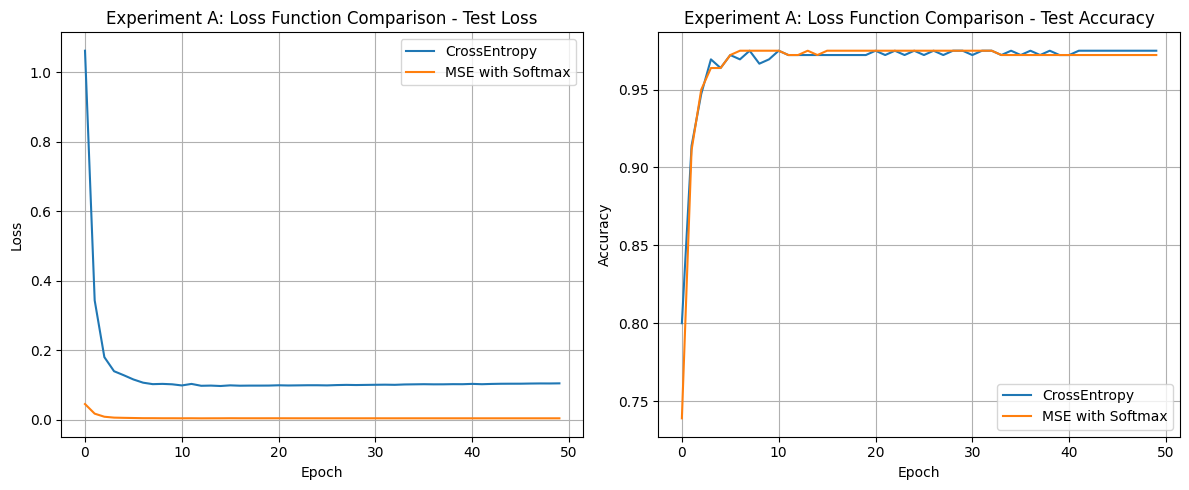

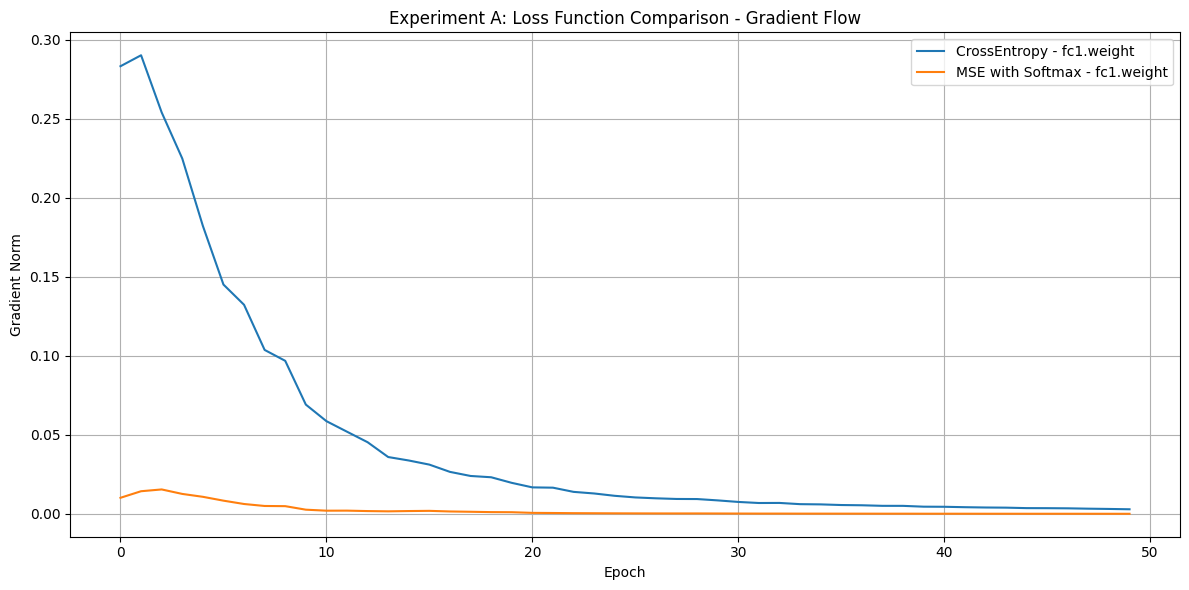

In [6]:
# CrossEntropyLoss와 MSELoss의 test loss/test accuracy 변화 비교
plot_loss_accuracy(
    expA_histories,
    title="Experiment A: Loss Function Comparison",
    save_path=os.path.join(RESULT_DIR, "expA_loss_accuracy.png")
)

# 두 손실 함수에서 첫 번째 layer의 gradient 크기 비교
plot_gradient_flow(
    expA_histories,
    title="Experiment A: Loss Function Comparison",
    save_path=os.path.join(RESULT_DIR, "expA_gradient_flow.png")
)


## A-4. 실험 A 정량 비교표

In [7]:
# 실험 A의 각 조건별 최종 정확도, 최소 loss, 수렴 epoch를 계산
for label, history in expA_histories.items():
    # 마지막 epoch의 test accuracy를 최종 정확도로 사용
    final_acc = history["test_acc"][-1] * 100

    # 전체 epoch 중 가장 낮았던 test loss 기록
    min_loss = min(history["test_loss"])

    # 수렴 epoch, test accuracy가 90% 이상에 처음 도달
    convergence_epoch = get_convergence_epoch(history["test_acc"], threshold=0.90)

    # 전체 summary table에 한 행씩 추가
    summary_rows.append({
        "Experiment": "A_Loss_Function",
        "Condition": label,
        "Learning_Rate": 0.001,
        "Final_Accuracy(%)": round(final_acc, 2),
        "Min_Loss": round(min_loss, 4),
        "Convergence_Epoch": convergence_epoch,
        "Extra_Info": "Digits Dataset"
    })

# 실험 A 결과만 추출하여 표로 출력
expA_table = pd.DataFrame([row for row in summary_rows if row["Experiment"] == "A_Loss_Function"])
print("[실험 A 정량 비교표]")
display(expA_table)


[실험 A 정량 비교표]


,Experiment,Condition,Learning_Rate,Final_Accuracy(%),Min_Loss,Convergence_Epoch,Extra_Info
0,A_Loss_Function,CrossEntropy,0.001,97.50,0.0967,2,Digits Dataset
1,A_Loss_Function,MSE with Softmax,0.001,97.22,0.0036,2,Digits Dataset


# 실험 B. 활성화 함수 비교

## B-0. 실험 조건

- 데이터셋: make_moons
- 모델 구조: 2 → 64 → 64 → 2
- 손실 함수: CrossEntropyLoss
- Optimizer: Adam
- Learning Rate: 0.01
- Epoch: 300
- 비교 대상: ReLU, LeakyReLU, Sigmoid

In [8]:
print("실험 B: 활성화 함수 비교")
# make_moons Dataset 로딩
train_loader_moons_B, test_loader_moons_B, X_train_moons_B, X_test_moons_B, y_train_moons_B, y_test_moons_B, input_size_moons_B, num_classes_moons_B = get_moons_loaders(
    batch_size=64,
    n_samples=1500,
    noise=0.25
)

# activation 이름 매핑
activation_settings = {
    "ReLU": "relu",
    "LeakyReLU": "leaky_relu",
    "Sigmoid": "sigmoid"
}

# 활성화 함수별 학습 기록, 모델, Dead 비율 저장
expB_histories = {}
expB_models = {}
dead_ratio_table = {}


실험 B: 활성화 함수 비교


## B-1. ReLU / LeakyReLU / Sigmoid 학습 및 시각화


[B] ReLU 학습 시작
Epoch [001/300] Train Loss: 0.5042, Train Acc: 0.8133, Test Loss: 0.3559, Test Acc: 0.8833
Epoch [010/300] Train Loss: 0.1505, Train Acc: 0.9358, Test Loss: 0.1680, Test Acc: 0.9200
Epoch [020/300] Train Loss: 0.1417, Train Acc: 0.9417, Test Loss: 0.1665, Test Acc: 0.9267
Epoch [030/300] Train Loss: 0.1445, Train Acc: 0.9425, Test Loss: 0.1657, Test Acc: 0.9333
Epoch [040/300] Train Loss: 0.1510, Train Acc: 0.9425, Test Loss: 0.1627, Test Acc: 0.9267
Epoch [050/300] Train Loss: 0.1416, Train Acc: 0.9400, Test Loss: 0.1792, Test Acc: 0.9233
Epoch [060/300] Train Loss: 0.1325, Train Acc: 0.9442, Test Loss: 0.1687, Test Acc: 0.9300
Epoch [070/300] Train Loss: 0.1299, Train Acc: 0.9475, Test Loss: 0.1645, Test Acc: 0.9267
Epoch [080/300] Train Loss: 0.1329, Train Acc: 0.9458, Test Loss: 0.1714, Test Acc: 0.9300
Epoch [090/300] Train Loss: 0.1276, Train Acc: 0.9458, Test Loss: 0.1681, Test Acc: 0.9300
Epoch [100/300] Train Loss: 0.1318, Train Acc: 0.9442, Test Loss: 0.1626, 

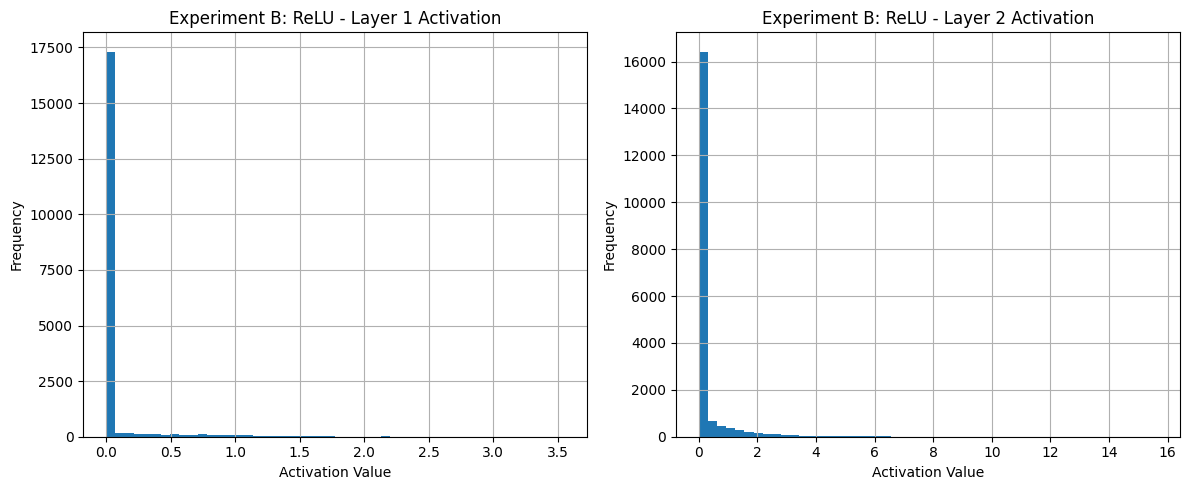

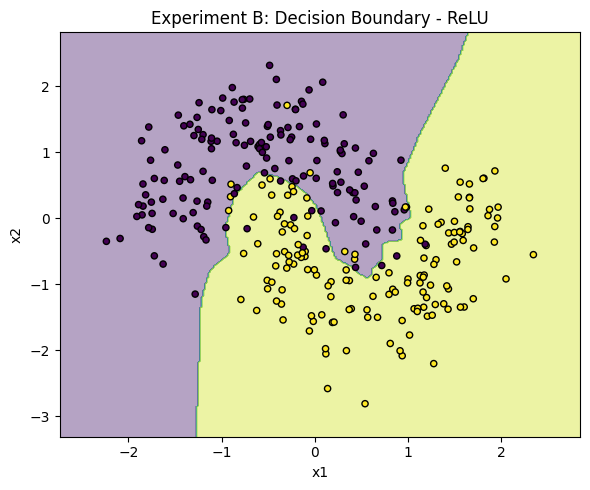


[B] LeakyReLU 학습 시작
Epoch [001/300] Train Loss: 0.4974, Train Acc: 0.8133, Test Loss: 0.3678, Test Acc: 0.8700
Epoch [010/300] Train Loss: 0.1488, Train Acc: 0.9400, Test Loss: 0.1585, Test Acc: 0.9300
Epoch [020/300] Train Loss: 0.1417, Train Acc: 0.9392, Test Loss: 0.1662, Test Acc: 0.9300
Epoch [030/300] Train Loss: 0.1406, Train Acc: 0.9400, Test Loss: 0.1659, Test Acc: 0.9233
Epoch [040/300] Train Loss: 0.1542, Train Acc: 0.9450, Test Loss: 0.1822, Test Acc: 0.9167
Epoch [050/300] Train Loss: 0.1404, Train Acc: 0.9400, Test Loss: 0.1772, Test Acc: 0.9300
Epoch [060/300] Train Loss: 0.1294, Train Acc: 0.9433, Test Loss: 0.1735, Test Acc: 0.9333
Epoch [070/300] Train Loss: 0.1277, Train Acc: 0.9433, Test Loss: 0.1704, Test Acc: 0.9300
Epoch [080/300] Train Loss: 0.1288, Train Acc: 0.9467, Test Loss: 0.1813, Test Acc: 0.9333
Epoch [090/300] Train Loss: 0.1235, Train Acc: 0.9458, Test Loss: 0.1666, Test Acc: 0.9367
Epoch [100/300] Train Loss: 0.1257, Train Acc: 0.9450, Test Loss: 0.1

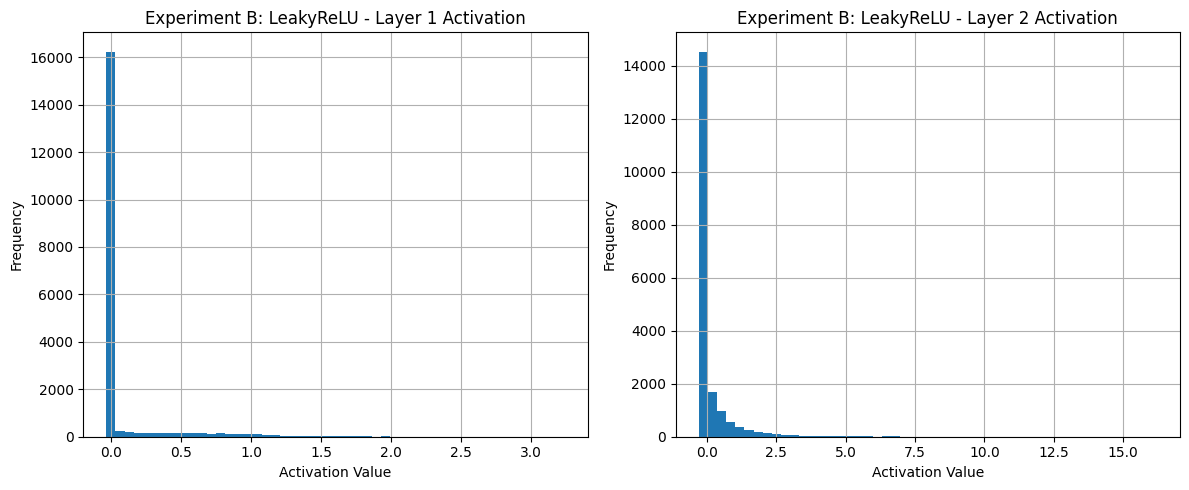

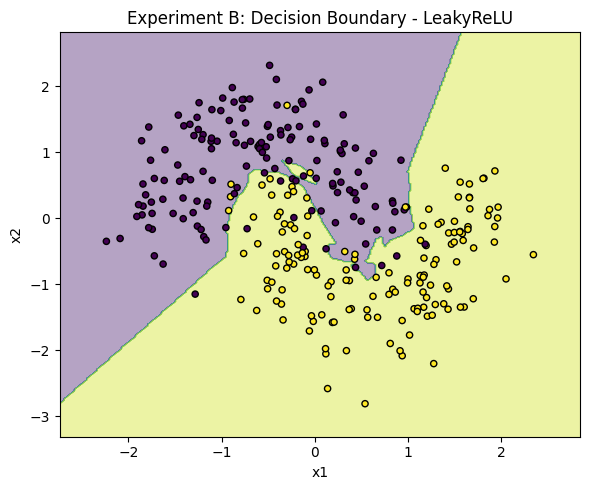


[B] Sigmoid 학습 시작
Epoch [001/300] Train Loss: 0.6992, Train Acc: 0.4933, Test Loss: 0.6945, Test Acc: 0.5000
Epoch [010/300] Train Loss: 0.3102, Train Acc: 0.8683, Test Loss: 0.3204, Test Acc: 0.8733
Epoch [020/300] Train Loss: 0.3087, Train Acc: 0.8708, Test Loss: 0.3101, Test Acc: 0.8767
Epoch [030/300] Train Loss: 0.3037, Train Acc: 0.8717, Test Loss: 0.3064, Test Acc: 0.8800
Epoch [040/300] Train Loss: 0.3119, Train Acc: 0.8683, Test Loss: 0.3096, Test Acc: 0.8733
Epoch [050/300] Train Loss: 0.3060, Train Acc: 0.8683, Test Loss: 0.3098, Test Acc: 0.8700
Epoch [060/300] Train Loss: 0.2973, Train Acc: 0.8700, Test Loss: 0.3099, Test Acc: 0.8700
Epoch [070/300] Train Loss: 0.2956, Train Acc: 0.8742, Test Loss: 0.3039, Test Acc: 0.8767
Epoch [080/300] Train Loss: 0.3027, Train Acc: 0.8683, Test Loss: 0.3017, Test Acc: 0.8767
Epoch [090/300] Train Loss: 0.2983, Train Acc: 0.8700, Test Loss: 0.3012, Test Acc: 0.8800
Epoch [100/300] Train Loss: 0.2964, Train Acc: 0.8725, Test Loss: 0.301

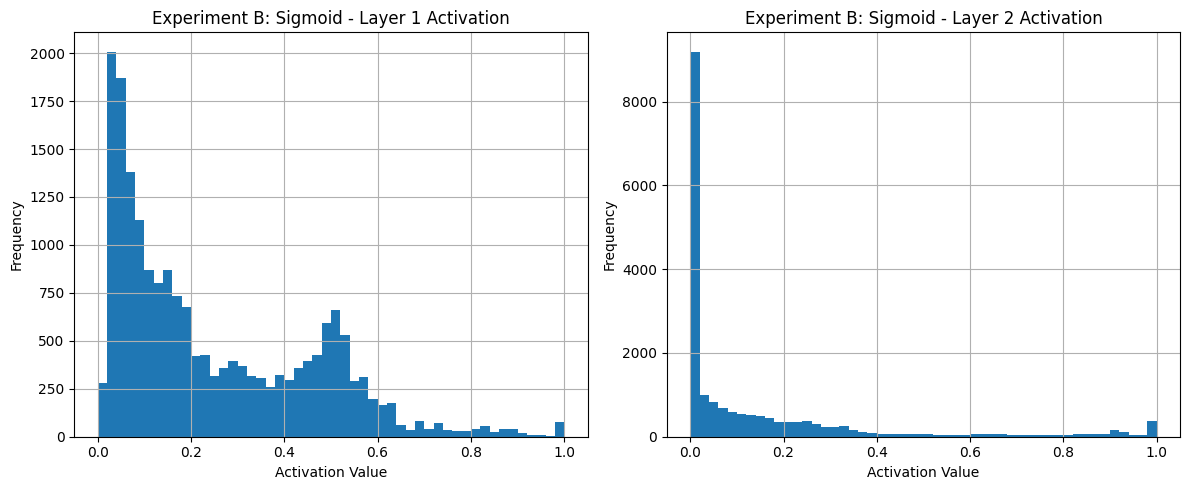

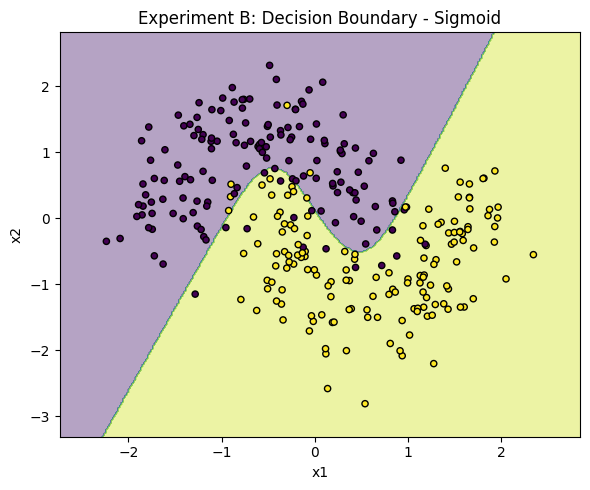

In [9]:
# 세 가지 활성화 함수를 같은 구조, 같은 loss, 같은 optimizer 조건에서 반복 실험
for label, activation_name in activation_settings.items():
    print(f"\n[B] {label} 학습 시작")

    # 동일한 초기 조건 위해 seed 고정
    torch.manual_seed(SEED)

    # make_moons는 2차원 입력이므로 SmallMLP 사용
    model = SmallMLP(
        activation_name=activation_name,
        small_init=True
    ).to(DEVICE)

    # 활성화 함수 비교에서는 손실 함수와 optimizer를 동일하게 유지
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    # 지정한 활성화 함수로 300 epoch 학습
    history = train_model(
        model=model,
        train_loader=train_loader_moons_B,
        test_loader=test_loader_moons_B,
        optimizer=optimizer,
        loss_fn=loss_fn,
        epochs=300,
        loss_mode="ce",
        num_classes=num_classes_moons_B
    )

    # 학습 기록과 모델 저장
    expB_histories[label] = history
    expB_models[label] = model

    # 학습 후 각 layer의 activation 값 히스토그램 저장
    plot_activation_distribution(
        model=model,
        data_loader=test_loader_moons_B,
        title=f"Experiment B: {label}",
        save_path=os.path.join(RESULT_DIR, f"expB_activation_distribution_{label}.png")
    )

    # 2차원 입력 공간에서 모델 분류 경계 시각화
    plot_decision_boundary(
        model=model,
        X=X_test_moons_B,
        y=y_test_moons_B,
        title=f"Experiment B: Decision Boundary - {label}",
        save_path=os.path.join(RESULT_DIR, f"expB_decision_boundary_{label}.png")
    )

    # layer별 Dead activation 비율 heatmap 생성
    dead_ratio_table[label] = calculate_dead_ratio(
        model=model,
        data_loader=test_loader_moons_B,
        activation_name=activation_name
    )


## B-2. 실험 B 그래프 생성

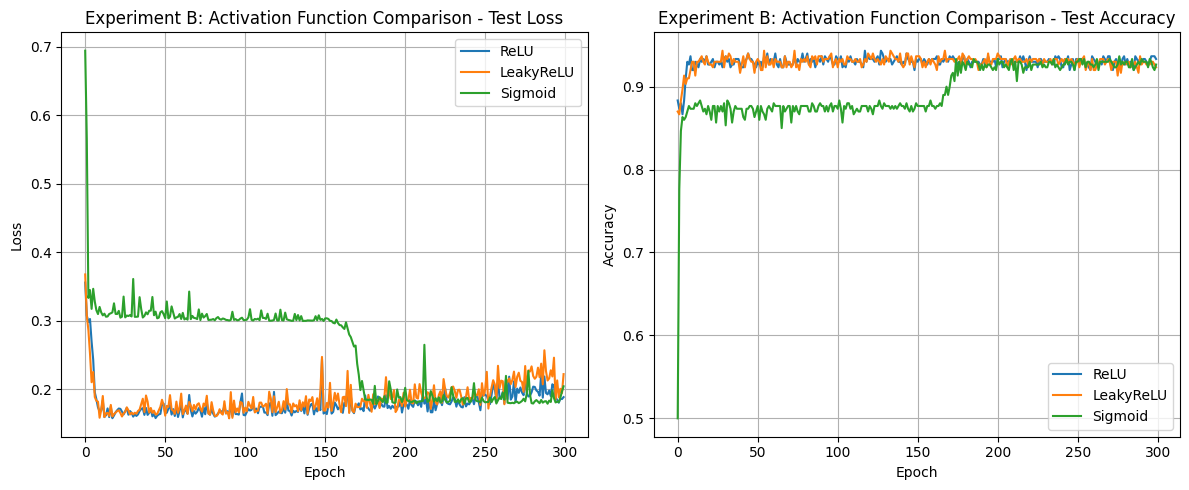

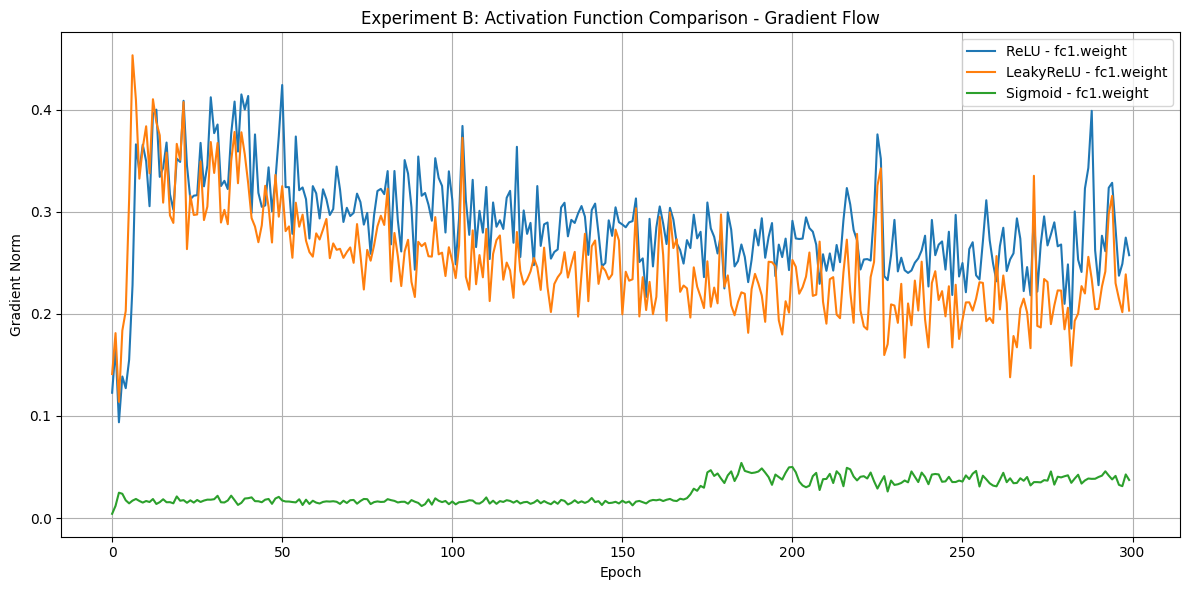

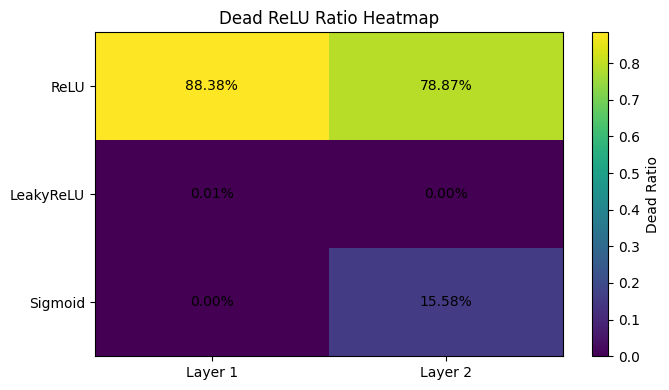

In [10]:
# 활성화 함수별 test loss/test accuracy 변화를 비교
plot_loss_accuracy(
    expB_histories,
    title="Experiment B: Activation Function Comparison",
    save_path=os.path.join(RESULT_DIR, "expB_loss_accuracy.png")
)

# 활성화 함수에 따라 첫 번째 layer의 gradient 흐름이 어떻게 달라지는지 비교
plot_gradient_flow(
    expB_histories,
    title="Experiment B: Activation Function Comparison",
    save_path=os.path.join(RESULT_DIR, "expB_gradient_flow.png")
)

# 활성화 함수별 layer1/layer2 Dead 비율 히트맵
plot_dead_relu_heatmap(
    dead_ratio_table=dead_ratio_table,
    save_path=os.path.join(RESULT_DIR, "expB_dead_relu_heatmap.png")
)


## B-3. 실험 B 정량 비교표

In [11]:
# 실험 B의 각 활성화 함수별 정량 지표 계산
for label, history in expB_histories.items():
    # 마지막 epoch의 test accuracy를 최종 정확도로 사용
    final_acc = history["test_acc"][-1] * 100

    # 전체 epoch 중 가장 낮은 test loss 기록
    min_loss = min(history["test_loss"])

    # 90% 정확도에 처음 도달한 epoch를 수렴 속도 지표로 사용
    convergence_epoch = get_convergence_epoch(history["test_acc"], threshold=0.90)

    # layer1과 layer2의 Dead 비율 평균 계산
    avg_dead_ratio = (dead_ratio_table[label]["layer1"] + dead_ratio_table[label]["layer2"]) / 2 * 100

    # 전체 summary table에 한 행씩 추가
    summary_rows.append({
        "Experiment": "B_Activation_Function",
        "Condition": label,
        "Learning_Rate": 0.01,
        "Final_Accuracy(%)": round(final_acc, 2),
        "Min_Loss": round(min_loss, 4),
        "Convergence_Epoch": convergence_epoch,
        "Extra_Info": f"Avg Dead Ratio: {avg_dead_ratio:.2f}%"
    })

# 실험 B 결과만 추출하여 표로 출력
expB_table = pd.DataFrame([row for row in summary_rows if row["Experiment"] == "B_Activation_Function"])
print("[실험 B 정량 비교표]")
display(expB_table)


[실험 B 정량 비교표]


,Experiment,Condition,Learning_Rate,Final_Accuracy(%),Min_Loss,Convergence_Epoch,Extra_Info
0,B_Activation_Function,ReLU,0.01,93.33,0.1578,6,Avg Dead Ratio: 83.62%
1,B_Activation_Function,LeakyReLU,0.01,92.33,0.1577,5,Avg Dead Ratio: 0.01%
2,B_Activation_Function,Sigmoid,0.01,92.67,0.1786,169,Avg Dead Ratio: 7.79%


# 실험 C. Optimizer 비교

## C-0. 실험 조건

- 데이터셋: Digits Dataset
- 모델 구조: 64 → 256 → 128 → 10
- 손실 함수: CrossEntropyLoss
- 활성화 함수: ReLU
- Epoch: 50
- Scheduler: ExponentialLR, gamma=0.9
- 비교 대상:
  - SGD: 0.1, 0.01, 0.001
  - SGD+Momentum: 0.05, 0.01, 0.001
  - Adam: 0.01, 0.001, 0.0001

In [12]:
print("실험 C: Optimizer 비교")

# Digits Dataset 로딩
train_loader_digits_C, test_loader_digits_C, input_size_digits_C, num_classes_digits_C = get_digits_loaders(batch_size=64)

# optimizer 종류와 learning rate 조합 리스트로 정의
optimizer_settings = [
    {"label": "SGD_lr_0.1", "type": "sgd", "lr": 0.1},
    {"label": "SGD_lr_0.01", "type": "sgd", "lr": 0.01},
    {"label": "SGD_lr_0.001", "type": "sgd", "lr": 0.001},
    {"label": "Momentum_lr_0.05", "type": "momentum", "lr": 0.05},
    {"label": "Momentum_lr_0.01", "type": "momentum", "lr": 0.01},
    {"label": "Momentum_lr_0.001", "type": "momentum", "lr": 0.001},
    {"label": "Adam_lr_0.01", "type": "adam", "lr": 0.01},
    {"label": "Adam_lr_0.001", "type": "adam", "lr": 0.001},
    {"label": "Adam_lr_0.0001", "type": "adam", "lr": 0.0001},
]

# optimizer 조건별 학습 기록 저장
expC_histories = {}


실험 C: Optimizer 비교


## C-1. Optimizer별 학습 실행

In [13]:
# 정의한 optimizer 설정을 하나씩 실행
for setting in optimizer_settings:
    # 현재 실험 조건의 이름, optimizer 종류, learning rate
    label = setting["label"]
    opt_type = setting["type"]
    lr = setting["lr"]

    print(f"\n[C] {label} 학습 시작")

    # 동일한 초기 조건 위해 seed 고정
    torch.manual_seed(SEED)

    # 모든 optimizer 실험에서 같은 MLP 구조와 ReLU 활성화 함수 사용
    model = MLP(
        input_size=input_size_digits_C,
        num_classes=num_classes_digits_C,
        activation_name="relu"
    ).to(DEVICE)

    # Optimizer 비교에서는 손실 함수를 CrossEntropyLoss로 고정
    loss_fn = nn.CrossEntropyLoss()

    # 설정값에 따라 optimizer 객체 생성
    if opt_type == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif opt_type == "momentum":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif opt_type == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError("지원하지 않는 optimizer type입니다.")

    # ExponentialLR은 매 epoch마다 learning rate를 gamma 배율만큼 감소
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

    # 현재 optimizer 조건으로 모델 학습
    history = train_model(
        model=model,
        train_loader=train_loader_digits_C,
        test_loader=test_loader_digits_C,
        optimizer=optimizer,
        loss_fn=loss_fn,
        epochs=50,
        loss_mode="ce",
        num_classes=num_classes_digits_C,
        scheduler=scheduler
    )

    # 그래프를 그리기 위해 조건별 history 저장
    expC_histories[label] = history

    # 정량 비교표에 넣을 지표 계산
    final_acc = history["test_acc"][-1] * 100
    min_loss = min(history["test_loss"])
    convergence_epoch = get_convergence_epoch(history["test_acc"], threshold=0.90)

    # 전체 summary table에 한 행씩 추가
    summary_rows.append({
        "Experiment": "C_Optimizer",
        "Condition": label,
        "Learning_Rate": lr,
        "Final_Accuracy(%)": round(final_acc, 2),
        "Min_Loss": round(min_loss, 4),
        "Convergence_Epoch": convergence_epoch,
        "Extra_Info": "ExponentialLR gamma=0.9"
    })



[C] SGD_lr_0.1 학습 시작
Epoch [001/50] Train Loss: 2.0741, Train Acc: 0.5261, Test Loss: 1.7275, Test Acc: 0.7083
Epoch [010/50] Train Loss: 0.1578, Train Acc: 0.9715, Test Loss: 0.1804, Test Acc: 0.9500
Epoch [020/50] Train Loss: 0.0965, Train Acc: 0.9847, Test Loss: 0.1425, Test Acc: 0.9583
Epoch [030/50] Train Loss: 0.0837, Train Acc: 0.9889, Test Loss: 0.1350, Test Acc: 0.9639
Epoch [040/50] Train Loss: 0.0799, Train Acc: 0.9903, Test Loss: 0.1326, Test Acc: 0.9639
Epoch [050/50] Train Loss: 0.0787, Train Acc: 0.9903, Test Loss: 0.1319, Test Acc: 0.9639

[C] SGD_lr_0.01 학습 시작
Epoch [001/50] Train Loss: 2.2766, Train Acc: 0.1726, Test Loss: 2.2560, Test Acc: 0.2139
Epoch [010/50] Train Loss: 1.9826, Train Acc: 0.6792, Test Loss: 1.9782, Test Acc: 0.6750
Epoch [020/50] Train Loss: 1.8016, Train Acc: 0.7182, Test Loss: 1.8095, Test Acc: 0.7194
Epoch [030/50] Train Loss: 1.7295, Train Acc: 0.7265, Test Loss: 1.7428, Test Acc: 0.7306
Epoch [040/50] Train Loss: 1.7035, Train Acc: 0.7293, T

## C-2. 실험 C Loss 그래프

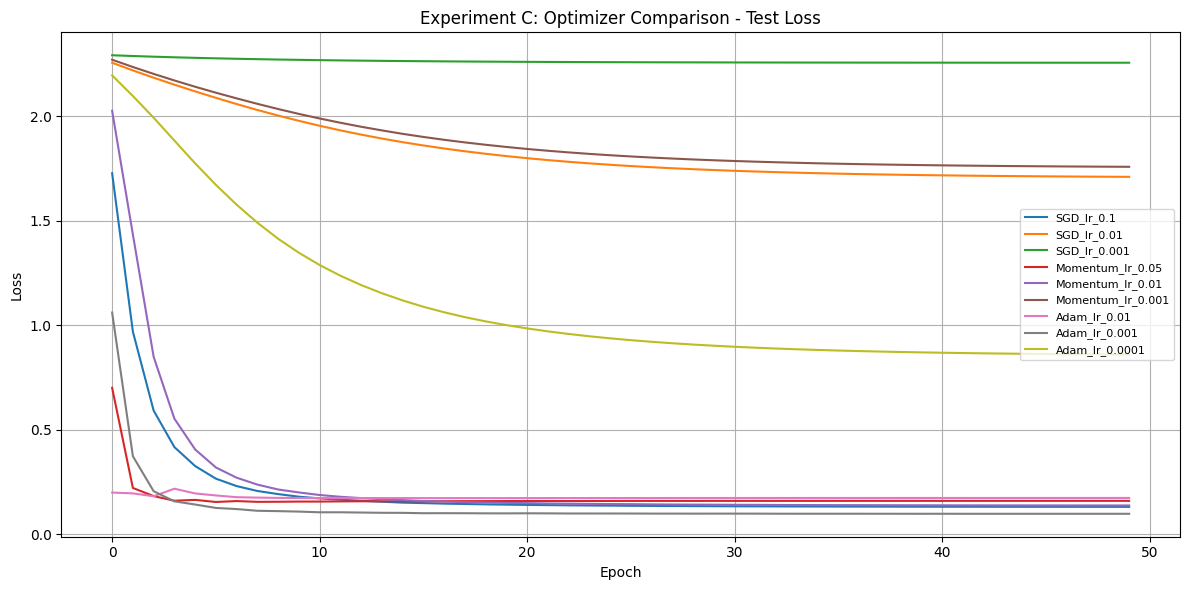

In [14]:
# Optimizer 조건별 test loss 곡선
plt.figure(figsize=(12, 6))
for label, history in expC_histories.items():
    plt.plot(history["test_loss"], label=label)
plt.title("Experiment C: Optimizer Comparison - Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "expC_optimizer_loss.png"), dpi=200)
plt.show()


## C-3. 실험 C Accuracy 그래프

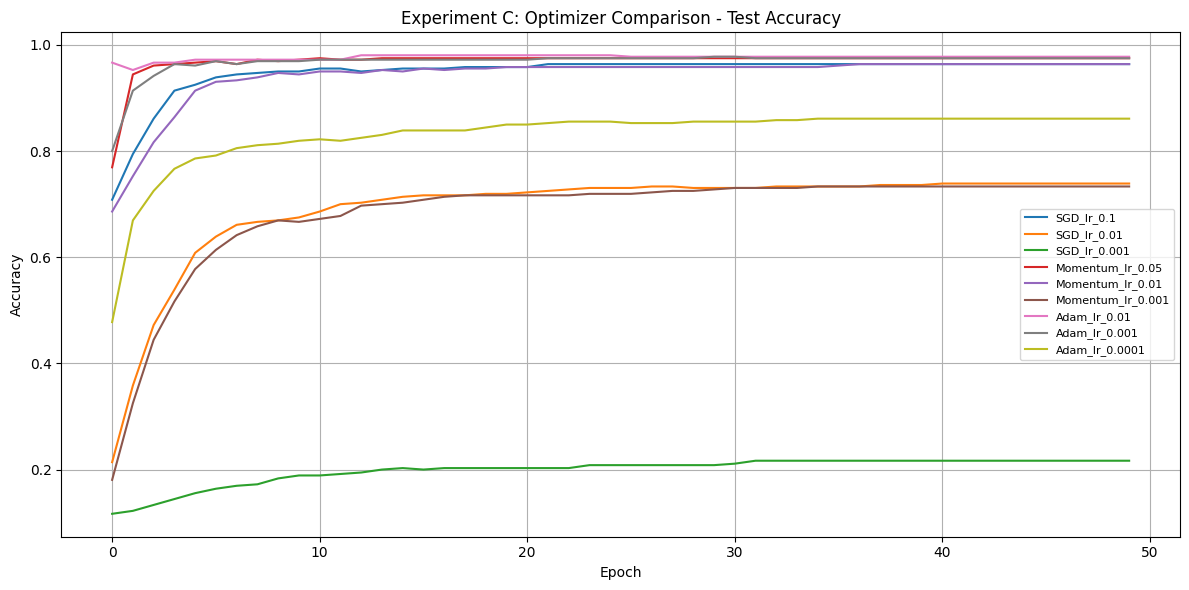

In [15]:
# Optimizer 조건별 test accuracy 곡선
plt.figure(figsize=(12, 6))
for label, history in expC_histories.items():
    plt.plot(history["test_acc"], label=label)
plt.title("Experiment C: Optimizer Comparison - Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "expC_optimizer_accuracy.png"), dpi=200)
plt.show()


## C-4. 대표 Optimizer Gradient Flow 비교

다음 세 가지를 비교

- SGD lr=0.01
- SGD+Momentum lr=0.01
- Adam lr=0.001

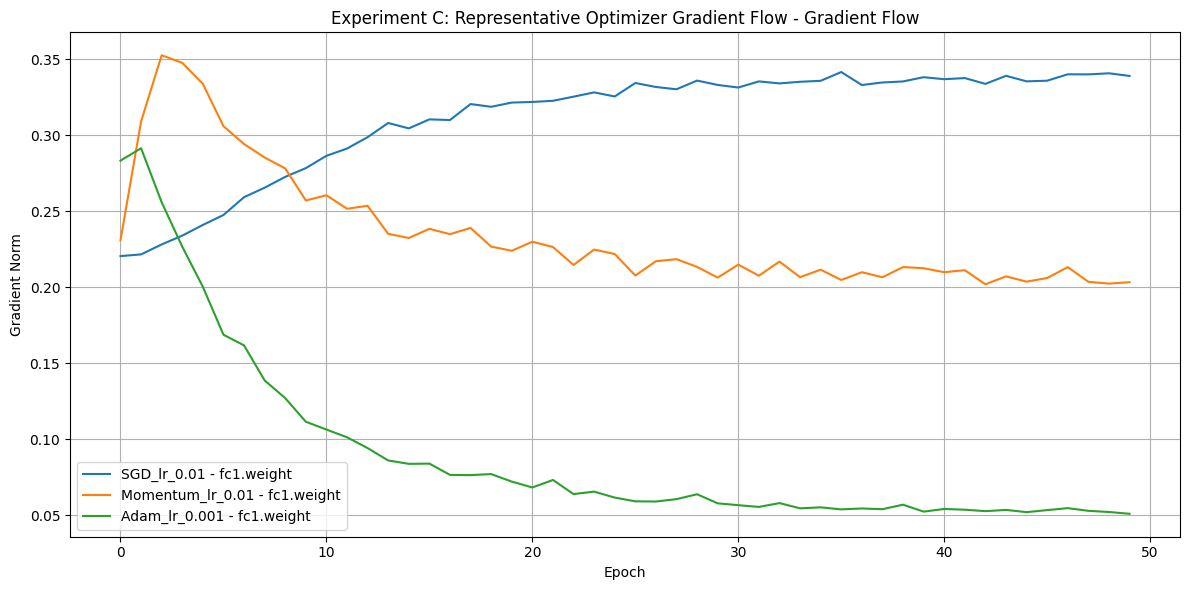

In [16]:
# 그래프가 너무 복잡해지지 않도록 대표 조건 3개만 gradient flow 비교에 사용
representative_expC = {
    "SGD_lr_0.01": expC_histories["SGD_lr_0.01"],
    "Momentum_lr_0.01": expC_histories["Momentum_lr_0.01"],
    "Adam_lr_0.001": expC_histories["Adam_lr_0.001"]
}

# 대표 optimizer 조건에서 첫 번째 layer의 gradient norm 변화 비교
plot_gradient_flow(
    representative_expC,
    title="Experiment C: Representative Optimizer Gradient Flow",
    save_path=os.path.join(RESULT_DIR, "expC_gradient_flow.png")
)


## C-5. 실험 C 정량 비교표

In [17]:
# 전체 summary_rows에서 실험 C에 해당하는 행만 뽑아 표로 출력
expC_table = pd.DataFrame([row for row in summary_rows if row["Experiment"] == "C_Optimizer"])
print("[실험 C 정량 비교표]")
display(expC_table)


[실험 C 정량 비교표]


,Experiment,Condition,Learning_Rate,Final_Accuracy(%),Min_Loss,Convergence_Epoch,Extra_Info
0,C_Optimizer,SGD_lr_0.1,0.1000,96.39,0.1319,4.0,ExponentialLR gamma=0.9
1,C_Optimizer,SGD_lr_0.01,0.0100,73.89,1.7103,NaN,ExponentialLR gamma=0.9
2,C_Optimizer,SGD_lr_0.001,0.0010,21.67,2.2561,NaN,ExponentialLR gamma=0.9
3,C_Optimizer,Momentum_lr_0.05,0.0500,97.50,0.1552,2.0,ExponentialLR gamma=0.9
4,C_Optimizer,Momentum_lr_0.01,0.0100,96.39,0.1385,5.0,ExponentialLR gamma=0.9
5,C_Optimizer,Momentum_lr_0.001,0.0010,73.33,1.7583,NaN,ExponentialLR gamma=0.9
6,C_Optimizer,Adam_lr_0.01,0.0100,97.78,0.1737,1.0,ExponentialLR gamma=0.9
7,C_Optimizer,Adam_lr_0.001,0.0010,97.50,0.0987,2.0,ExponentialLR gamma=0.9
8,C_Optimizer,Adam_lr_0.0001,0.0001,86.11,0.8599,NaN,ExponentialLR gamma=0.9


# 전체 결과 저장 및 확인

실험 A, B, C의 정량 비교 결과를 하나의 CSV 파일로 저장

In [18]:
summary_df = pd.DataFrame(summary_rows)

summary_csv_path = os.path.join(RESULT_DIR, "summary_tables.csv")
summary_df.to_csv(summary_csv_path, index=False, encoding="utf-8-sig")

print("전체 실험 요약표")
display(summary_df)

print(f"\n요약 CSV 저장 완료: {summary_csv_path}")

print("\n생성된 결과 파일 목록:")
for filename in sorted(os.listdir(RESULT_DIR)):
    print("-", filename)


전체 실험 요약표


,Experiment,Condition,Learning_Rate,Final_Accuracy(%),Min_Loss,Convergence_Epoch,Extra_Info
0,A_Loss_Function,CrossEntropy,0.0010,97.50,0.0967,2.0,Digits Dataset
1,A_Loss_Function,MSE with Softmax,0.0010,97.22,0.0036,2.0,Digits Dataset
2,B_Activation_Function,ReLU,0.0100,93.33,0.1578,6.0,Avg Dead Ratio: 83.62%
3,B_Activation_Function,LeakyReLU,0.0100,92.33,0.1577,5.0,Avg Dead Ratio: 0.01%
4,B_Activation_Function,Sigmoid,0.0100,92.67,0.1786,169.0,Avg Dead Ratio: 7.79%
5,C_Optimizer,SGD_lr_0.1,0.1000,96.39,0.1319,4.0,ExponentialLR gamma=0.9
6,C_Optimizer,SGD_lr_0.01,0.0100,73.89,1.7103,NaN,ExponentialLR gamma=0.9
7,C_Optimizer,SGD_lr_0.001,0.0010,21.67,2.2561,NaN,ExponentialLR gamma=0.9
8,C_Optimizer,Momentum_lr_0.05,0.0500,97.50,0.1552,2.0,ExponentialLR gamma=0.9
9,C_Optimizer,Momentum_lr_0.01,0.0100,96.39,0.1385,5.0,ExponentialLR gamma=0.9



요약 CSV 저장 완료: results/summary_tables.csv

생성된 결과 파일 목록:
- expA_gradient_flow.png
- expA_loss_accuracy.png
- expB_activation_distribution_LeakyReLU.png
- expB_activation_distribution_ReLU.png
- expB_activation_distribution_Sigmoid.png
- expB_dead_relu_heatmap.png
- expB_decision_boundary_LeakyReLU.png
- expB_decision_boundary_ReLU.png
- expB_decision_boundary_Sigmoid.png
- expB_gradient_flow.png
- expB_loss_accuracy.png
- expC_gradient_flow.png
- expC_optimizer_accuracy.png
- expC_optimizer_loss.png
- summary_tables.csv
